## Convocatoria 1 - Proyecto 1

#### 0) Cargar una de las imágenes histológicas

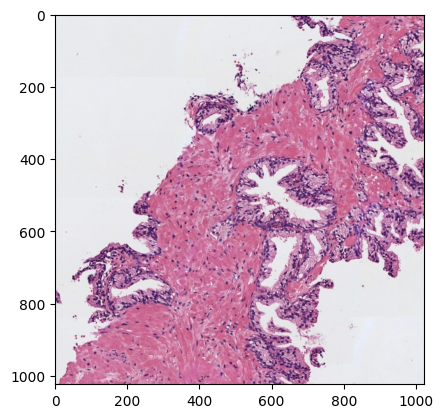

In [31]:
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
import cv2

def nomalizar_visualizar(ruta_imagen):
    # Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
    img = io.imread(ruta_imagen)
    
    # Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
    rgb = img.copy()
    rgb_normalizada = rgb.astype('uint8')/255
    
    # Visualizar la imagen
    plt.imshow(rgb_normalizada)
    plt.show()

    return rgb_normalizada.copy()

histo_1_normalizada = nomalizar_visualizar('./histo_1.jpg')

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

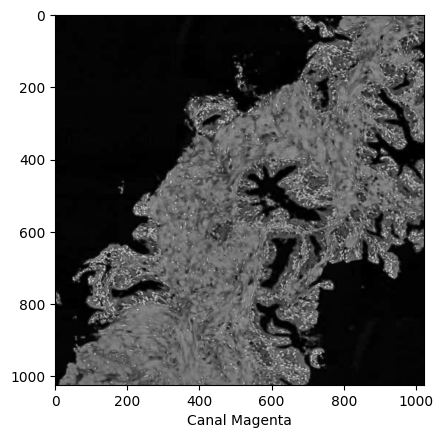

In [81]:
def obtener_CMYK(imagen_normalizada):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(imagen_normalizada, axis=2)
        C = (1-imagen_normalizada[:,:,0]-K)/(1-K)
        M = (1-imagen_normalizada[:,:,1]-K)/(1-K)
        Y = (1-imagen_normalizada[:,:,2]-K)/(1-K)
    
    CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
    C,M,Y,K = cv2.split(CMYK)
    return C,M,Y,K

def visualizar_imagen(imagen, titulo):
    fig, axes = plt.subplots(1, 1, figsize=(10, 4))
    axes.imshow(imagen, cmap='gray');   
    axes.set_title(titulo);        
    axes.set_xticks([]); 
    axes.set_yticks([])
    axes.set_visible(True)
    plt.show()

    
    
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta
histo_1_C, histo_1_M, histo_1_Y, histo_1_K = obtener_CMYK(histo_1_normalizada)
visualizar_canal(histo_1_M.astype('uint8'), 'Canal Magenta')

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

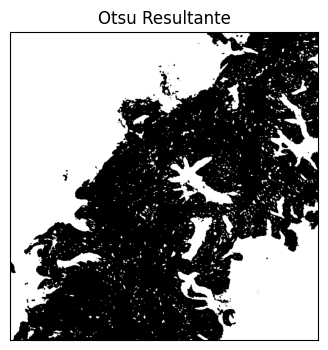

In [82]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

def transformar_imagen_a_float32(imagen):
  imagen_float_32 = imagen.astype(np.float32)
  return imagen_float_32


def aplicar_filtro_gauss_outsu_y_visualizar(imagen):
    imagen_32 = transformar_imagen_a_float32(imagen) # Se transforma a 32 float para poder escalar a grices con cv2.cvtColor
    imagen_32_gray = cv2.cvtColor(imagen_32, cv2.COLOR_BGR2GRAY)
    imagen_gray_u8 = (imagen_32_gray.astype(np.float32) * 255).clip(0, 255).astype(np.uint8) # Se pasa a u8 la escala de grises para poder graficar

    gaussian_blur = cv2.GaussianBlur(imagen_gray_u8, (5, 5), 0)
    _, gaussian_blur_mask = cv2.threshold(gaussian_blur, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_mask = cv2.threshold(gaussian_blur_mask, 0, 1, cv2.THRESH_OTSU)

    visualizar_imagen(otsu_mask, "Otsu Resultante")

    return otsu_mask


histo_1_otsu_mask = aplicar_filtro_gauss_outsu_y_visualizar(histo_1_normalizada)

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

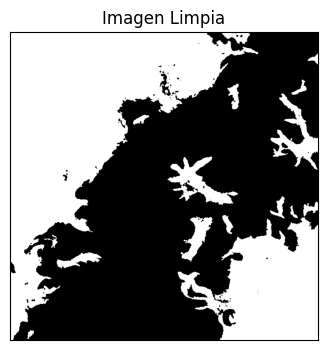

In [88]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante
from skimage.morphology import remove_small_objects

histo_1_bool = histo_1_otsu_mask.astype(bool)
histo_1_limpia = remove_small_objects(histo_1_bool, min_size=301)
visualizar_imagen(histo_1_limpia, "Imagen Limpia")

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [ ]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

#### 5) Rellenar los objetos de los lúmenes

In [ ]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [ ]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

#### 7) Identificar y cropear el lumen más grande

In [ ]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [ ]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad